In [2]:
import os

os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
# os.getenv("GROQ_API_KEY")

from langchain.chat_models import init_chat_model

model = init_chat_model("groq:openai/gpt-oss-safeguard-20b")



In [3]:
from langchain_tavily import TavilySearch

tavily_search_tool = TavilySearch(
    max_results=1,
    topic="general",
    # include_answer=False,
    # include_raw_content=False,
    # include_images=False,
    # include_image_descriptions=False,
    # search_depth="basic",
    # time_range="day",
    # start_date=None,
    # end_date=None,
    # include_domains=None,
    # exclude_domains=None,
    # include_usage= False
)

tavily_search_tool.invoke("What is the current AI news")

{'query': 'What is the current AI news',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.wsj.com/tech/ai',
   'title': 'Artificial Intelligence - Latest AI News and Analysis - WSJ.com',
   'content': 'Google Unveils New Gemini AI Agent for Personal Tasks · The tech firm highlights both Spark and Omni, a video-creation tool, at its annual developer conference.',
   'score': 0.6685563,
   'raw_content': None}],
 'response_time': 0.65,
 'request_id': '56a711b4-2656-42be-9506-e3d40b02b726'}

In [52]:
from langchain.tools import tool

@tool("calculator", description="Performs arithmetic calculations. Use this for any math problems.")
def calc(expression: str) -> str:
    """Evaluate mathematical expressions."""
    return str(eval(expression))

tool

<function langchain_core.tools.convert.tool(name_or_callable: str | collections.abc.Callable | None = None, runnable: langchain_core.runnables.base.Runnable | None = None, *args: Any, description: str | None = None, return_direct: bool = False, args_schema: type[pydantic.main.BaseModel] | dict[str, typing.Any] | None = None, infer_schema: bool = True, response_format: Literal['content', 'content_and_artifact'] = 'content', parse_docstring: bool = False, error_on_invalid_docstring: bool = True, extras: dict[str, typing.Any] | None = None) -> langchain_core.tools.base.BaseTool | collections.abc.Callable[[collections.abc.Callable | langchain_core.runnables.base.Runnable], langchain_core.tools.base.BaseTool]>

In [53]:
from langchain.agents import create_agent

agent = create_agent(
    model=model,
    tools=[tavily_search_tool,calc]
)

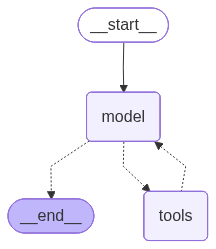

In [54]:
agent

In [55]:
user_input="What is the current AI news for Anthropic and then calculate 5+5"

for step in agent.stream(
    {"messages": user_input},
    stream_mode="values"
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

What is the current AI news for Anthropic and then calculate 5+5
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_90fb891d-4e4b-4607-ab45-b1098187e41f)
 Call ID: fc_90fb891d-4e4b-4607-ab45-b1098187e41f
  Args:
    query: Anthropic current AI news 2026
    search_depth: basic
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "Anthropic current AI news 2026", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.nytimes.com/2026/04/22/technology/anthropics-mythos-ai.html", "title": "Anthropic's New Mythos A.I. Model Sets Off Global Alarms", "content": "Anthropic's New A.I. Model Sets Off Global Alarms. Mythos has triggered emergency responses from central banks and intelligence agencies", "score": 0.86331123, "raw_content": null}]

In [58]:
agent.invoke({"messages":"What is the current AI news"})

{'messages': [HumanMessage(content='What is the current AI news', additional_kwargs={}, response_metadata={}, id='2e8e1fe9-c655-4e7b-9e40-094fa6505a8c'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'The user asks: "What is the current AI news". Need to provide current AI news. We should browse recent news. Use search.', 'tool_calls': [{'id': 'fc_0dea49ed-c62b-4942-8584-dcd6a95cb412', 'function': {'arguments': '{"query":"current AI news 2026","search_depth":"advanced","topic":"news"}', 'name': 'tavily_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 70, 'prompt_tokens': 344, 'total_tokens': 414, 'completion_time': 0.070416843, 'completion_tokens_details': {'reasoning_tokens': 29}, 'prompt_time': 0.005369377, 'prompt_tokens_details': {'cached_tokens': 256}, 'queue_time': 0.051374248, 'total_time': 0.07578622}, 'model_name': 'openai/gpt-oss-safeguard-20b', 'system_fingerprint': 'fp_b5ae46a825', 'service_tier': 'on_demand', 'finis